In [1]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms

In [2]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os 
class Training_Val_Dataset(Dataset):
    def __init__(self,img_folder,str_folder,transform=None):
        self.img_folder=img_folder
        self.images=sorted([file for file in os.listdir(img_folder)
                            if file.lower().endswith((".png"))])
        with open(str_folder,"r") as f:
            self.steering=[float(line.strip()) for line in f.readlines()]
        self.transform=transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):
        img_path=os.path.join(self.img_folder,self.images[idx])
        image=Image.open(img_path).convert("RGB")
        angle=self.steering[idx]

        if self.transform:
            image=self.transform(image)
        return image,torch.tensor(angle,dtype=torch.float32)
        

In [3]:
#Created a class to apply the tranform pipelines on the dataset
import random
class TransformerDataset(torch.utils.data.Dataset):
    def __init__(self,df,transformation_pipeline,random_horizontal_flip=False):
        self.df=df
        self.transform=transformation_pipeline
        self.random_horizontal_flip=random_horizontal_flip
    def __len__(self):
        return len(self.df)
    def __getitem__(self,index):
        img,label=self.df[index]
        if self.random_horizontal_flip and random.random()>0.5:
            img=transforms.functional.hflip(img)
            label=-label
        return self.transform(img),label
        

In [4]:
df=Training_Val_Dataset(img_folder="/kaggle/input/datasets/zahidbooni/alltownswithweather/Data/Images",str_folder="/kaggle/input/datasets/zahidbooni/alltownswithweather/Data/SteerValues/steer_values.txt",transform=None)

In [5]:
#Splitting the dataset, before applying augmentation on the training set
torch.manual_seed(42)
from torch.utils.data import random_split
train_size=int(0.8*len(df))
val_size=len(df)-train_size
df_train,df_val=random_split(df,[train_size,val_size])

In [6]:
train_pipeline=transforms.Compose([transforms.Resize((66,200)),
                                   transforms.ColorJitter(brightness=0.2,contrast=0.2),
                                   transforms.RandomGrayscale(p=0.05),transforms.ToTensor(),
                                   transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])
#Normalization Pipeline
val_test_pipeline=transforms.Compose([transforms.Resize((66,200)),transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])])

In [7]:
df_train=TransformerDataset(df_train,train_pipeline,random_horizontal_flip=True)
df_val=TransformerDataset(df_val,val_test_pipeline)

In [8]:
def test_dataset(weather):
      test_path=("/kaggle/input/datasets/zahidbooni/alltownswithweather/testing_data")
      folder=os.path.join(test_path,weather)
      raw_df_test=Training_Val_Dataset(img_folder=folder,str_folder=os.path.join(folder,"steer_values.txt"),transform=None)
      df_test=TransformerDataset(raw_df_test,val_test_pipeline,random_horizontal_flip=False)
      return df_test

In [9]:
df_test_ClearNoon=test_dataset("ClearNoon")
df_test_ClearSunset=test_dataset("ClearSunset")
df_test_CloudyNoon=test_dataset("CloudyNoon")
df_test_CloudySunset=test_dataset("CloudySunset")
df_test_HardRainNoon=test_dataset("HardRainNoon")
df_test_HardRainSunset=test_dataset("HardRainSunset")
df_test_MidRainSunset=test_dataset("MidRainSunset")
df_test_MidRainyNoon=test_dataset("MidRainyNoon")
df_test_SoftRainNoon=test_dataset("SoftRainNoon")
df_test_SoftRainSunset=test_dataset("SoftRainSunset")
df_test_WetCloudyNoon=test_dataset("WetCloudyNoon")
df_test_WetCloudySunset=test_dataset("WetCloudySunset")
df_test_WetNoon=test_dataset("WetNoon")
df_test_WetSunset=test_dataset("WetSunset")

In [10]:
if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"

In [11]:
#Since the data is dominated by zero or very close to zero values, weighted sampling was added so that
#model doesn't only learn to predict zero
import numpy as np
from torch.utils.data import WeightedRandomSampler
angles=np.array([df.steering[i] for i in df_train.df.indices])
weights=np.abs(angles)+0.1
sampler=WeightedRandomSampler(weights,num_samples=len(weights),replacement=True)

In [12]:
from torch.utils.data import DataLoader
train_loader=DataLoader(df_train,sampler=sampler,batch_size=64,num_workers=4)
val_loader=DataLoader(df_val,shuffle=False,batch_size=64,num_workers=4)


test_loader_ClearNoon=DataLoader(df_test_ClearNoon,shuffle=False,batch_size=64,num_workers=4)
test_loader_ClearSunset=DataLoader(df_test_ClearSunset,shuffle=False,batch_size=64,num_workers=4)
test_loader_CloudyNoon=DataLoader(df_test_CloudyNoon,shuffle=False,batch_size=64,num_workers=4)
test_loader_CloudySunset=DataLoader(df_test_CloudySunset,shuffle=False,batch_size=64,num_workers=4)
test_loader_HardRainNoon=DataLoader(df_test_HardRainNoon,shuffle=False,batch_size=64,num_workers=4)
test_loader_HardRainSunset=DataLoader(df_test_HardRainSunset,shuffle=False,batch_size=64,num_workers=4)
test_loader_MidRainSunset=DataLoader(df_test_MidRainSunset,shuffle=False,batch_size=64,num_workers=4)
test_loader_MidRainyNoon=DataLoader(df_test_MidRainyNoon,shuffle=False,batch_size=64,num_workers=4)
test_loader_SoftRainNoon=DataLoader(df_test_SoftRainNoon,shuffle=False,batch_size=64,num_workers=4)
test_loader_SoftRainSunset=DataLoader(df_test_SoftRainSunset,shuffle=False,batch_size=64,num_workers=4)
test_loader_WetCloudyNoon=DataLoader(df_test_WetCloudyNoon,shuffle=False,batch_size=64,num_workers=4)
test_loader_WetCloudySunset=DataLoader(df_test_WetCloudySunset,shuffle=False,batch_size=64,num_workers=4)
test_loader_WetNoon=DataLoader(df_test_WetNoon,shuffle=False,batch_size=64,num_workers=4)
test_loader_WetSunset=DataLoader(df_test_WetSunset,shuffle=False,batch_size=64,num_workers=4)

In [13]:
class PilotNet(nn.Module):
    def __init__(self,n_image_channel):
        super().__init__()
        self.cnn_layer=nn.Sequential(nn.Conv2d(n_image_channel,out_channels=24,kernel_size=5,stride=2),
                                     nn.ReLU(),
                                     nn.Conv2d(24,out_channels=36,kernel_size=5,stride=2),
                                     nn.ReLU(),
                                     nn.Conv2d(36,out_channels=48,kernel_size=5,stride=2),
                                     nn.ReLU(),
                                     nn.Conv2d(48,out_channels=64,kernel_size=3,stride=1),
                                     nn.ReLU(),
                                     nn.Conv2d(64,out_channels=64,kernel_size=3,stride=1),
                                     nn.ReLU(),
                                     nn.Flatten())
        
        self.fcl=nn.Sequential(nn.Linear(1152,100),
                               nn.ReLU(),
                               nn.Linear(100,50),
                               nn.ReLU(),
                               nn.Linear(50,10),
                               nn.ReLU(),
                               nn.Linear(10,1))

    def forward(self,X):
        output=self.cnn_layer(X)
        final_output=self.fcl(output)
        return final_output

In [14]:
model=PilotNet(n_image_channel=3).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=0.001,betas=(0.9,0.999),weight_decay=1e-4)
criterion=nn.MSELoss()
learning_rate_scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="min",patience=5,factor=0.5,min_lr=1e-6)

In [15]:
#Training consists of early stopping with a patience of 10 and maximum epochs as n_epochs
losses_list=list()
val_losses_list=list()
def training(train_loader,val_loader,model,optimizer,criterion,learning_rate_scheduler,n_epochs):
    best_val_loss=float("inf")
    patience=0

    for epoch in range(n_epochs):
        model.train()
        losses=0.0
        if patience>9:
            break
        for image_batch,label_batch in train_loader:
            image_batch=image_batch.to(device)
            label_batch=label_batch.to(device)
            label_batch=label_batch.float().unsqueeze(1)
            optimizer.zero_grad()
            y_preds=model(image_batch)
            loss=criterion(y_preds,label_batch)
            loss.backward()
            optimizer.step()
            losses+=loss.item()
        mean_loss=losses/len(train_loader)
        losses_list.append(mean_loss**0.5)

        model.eval()
        with torch.no_grad():
         val_losses=0
         for image_batch,label_batch in val_loader:
          image_batch=image_batch.to(device)
          label_batch=label_batch.to(device)
          label_batch=label_batch.float().unsqueeze(1)
          y_preds=model(image_batch)
          val_losses+=criterion(y_preds,label_batch).item()
        val_loss=val_losses/len(val_loader)
        val_losses_list.append(val_loss**0.5)
        learning_rate_scheduler.step(val_loss)
        print(f"Epoch:{epoch},Training RMSE Loss:{mean_loss**0.5},Val_RMSE Loss:{val_loss**0.5:.5f}",flush=True)
        
        #Early Stopping
        if val_loss<best_val_loss:
            best_val_loss=val_loss
            best_epoch=epoch
            best_model=model.state_dict().copy()
            patience=0 #We only track patience for consecutive non-repeating loops
        else:
            patience+=1
    
    #Saving the best model for evaluation purposes 
    torch.save(best_model,"/kaggle/working/bestmodel.pth")
    print(f"The best model is found at the epoch:{best_epoch} with a validation RMSE loss of {best_val_loss**0.5}")

In [16]:
#Evaluation Function
def eval(test_loader,model,criterion):
    model.eval()
    test_loss=0.0
    with torch.no_grad():
     for image_batch,label_batch in test_loader:
        image_batch=image_batch.to(device)
        label_batch=label_batch.to(device)
        label_batch=label_batch.float().unsqueeze(1)
        y_preds=model(image_batch)
        test_loss+=criterion(y_preds,label_batch).item()
     mean_test_loss=test_loss/len(test_loader)
     return mean_test_loss**0.5
        

In [17]:
#Maximum epochs set to 100
training(train_loader,val_loader,model,optimizer,criterion,learning_rate_scheduler,n_epochs=100)

Epoch:0,Training RMSE Loss:0.1251801044061055,Val_RMSE Loss:0.06089
Epoch:1,Training RMSE Loss:0.08107365669686627,Val_RMSE Loss:0.04866
Epoch:2,Training RMSE Loss:0.06808731924899993,Val_RMSE Loss:0.05102
Epoch:3,Training RMSE Loss:0.06504035168573366,Val_RMSE Loss:0.04171
Epoch:4,Training RMSE Loss:0.05866921679058692,Val_RMSE Loss:0.04239
Epoch:5,Training RMSE Loss:0.05840769159864046,Val_RMSE Loss:0.04522
Epoch:6,Training RMSE Loss:0.057243645898789726,Val_RMSE Loss:0.03765
Epoch:7,Training RMSE Loss:0.054230700957540026,Val_RMSE Loss:0.04422
Epoch:8,Training RMSE Loss:0.054366670226304654,Val_RMSE Loss:0.03533
Epoch:9,Training RMSE Loss:0.05355519183634364,Val_RMSE Loss:0.03764
Epoch:10,Training RMSE Loss:0.052276058783388764,Val_RMSE Loss:0.04070
Epoch:11,Training RMSE Loss:0.04997848941551866,Val_RMSE Loss:0.03581
Epoch:12,Training RMSE Loss:0.05025293206345651,Val_RMSE Loss:0.03755
Epoch:13,Training RMSE Loss:0.05036040532505363,Val_RMSE Loss:0.03694
Epoch:14,Training RMSE Loss

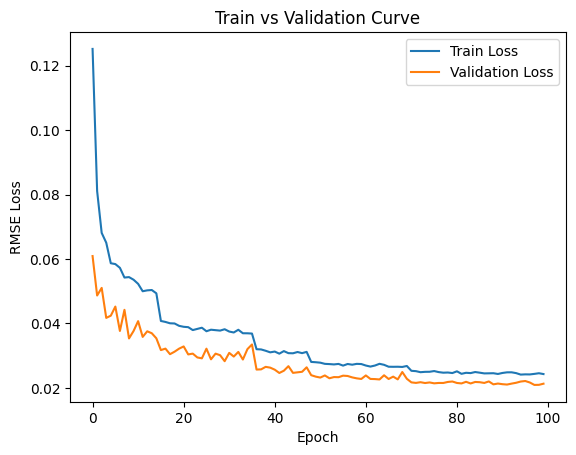

In [18]:
#Training Vs Validation Loss Plot
import matplotlib.pyplot as plt
plt.plot(losses_list,label="Train Loss")
plt.plot(val_losses_list,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("RMSE Loss")
plt.title("Train vs Validation Curve")
plt.legend()
plt.show()

In [19]:
#Using the best model found in training during the process of Early Stopping for evaluation of TEST Set
model.load_state_dict(torch.load('/kaggle/working/bestmodel.pth'))
#Test RMSE Loss for all the Test Folders
print(f"ClearNoon RMSE:{eval(test_loader_ClearNoon,model,criterion)}")
print(f"ClearSunset RMSE:{eval(test_loader_ClearSunset,model,criterion)}")
print(f"CloudyNoon RMSE:{eval(test_loader_CloudyNoon,model,criterion)}")
print(f"CloudySunset RMSE:{eval(test_loader_CloudySunset,model,criterion)}")
print(f"HardRainNoon RMSE:{eval(test_loader_HardRainNoon,model,criterion)}")
print(f"HardRainSunset RMSE:{eval(test_loader_HardRainSunset,model,criterion)}")
print(f"MidRainSunset RMSE:{eval(test_loader_MidRainSunset,model,criterion)}")
print(f"MidRainyNoon RMSE:{eval(test_loader_MidRainyNoon,model,criterion)}")
print(f"SoftRainNoon RMSE:{eval(test_loader_SoftRainNoon,model,criterion)}")
print(f"SoftRainSunset RMSE:{eval(test_loader_SoftRainSunset,model,criterion)}")
print(f"WetCloudyNoon RMSE:{eval(test_loader_WetCloudyNoon,model,criterion)}")
print(f"WetCloudySunset RMSE:{eval(test_loader_WetCloudySunset,model,criterion)}")
print(f"WetNoon RMSE:{eval(test_loader_WetNoon,model,criterion)}")
print(f"WetSunset RMSE:{eval(test_loader_WetSunset,model,criterion)}")

ClearNoon RMSE:0.028712262722142314
ClearSunset RMSE:0.047643369432690985
CloudyNoon RMSE:0.023391180929725582
CloudySunset RMSE:0.02480548217015696
HardRainNoon RMSE:0.022198250902459884
HardRainSunset RMSE:0.026986131483737553
MidRainSunset RMSE:0.029141723903314307
MidRainyNoon RMSE:0.022768726966672898
SoftRainNoon RMSE:0.02202398620331097
SoftRainSunset RMSE:0.025310536082775954
WetCloudyNoon RMSE:0.022840517309445234
WetCloudySunset RMSE:0.02598834458501384
WetNoon RMSE:0.028911852795311083
WetSunset RMSE:0.03894934791278207


In [20]:
#Gradcam class to hook,generate the CAM tensor and display it 
class GradCam():
    def __init__(self):
        self.forward_value=None                   #Initially setting the activations in the hook as zero
        self.back_gradient=None                   #Initially setting the gradients in the hook as zero

    
    def forward(self,module,input,output):        
        self.forward_value=output                 #self.forward_value stores the activations of the hook layer
           
    def backward(self,module,input,gradient_output):
        self.back_gradient=gradient_output[0]     #self.back_gradient stores the gradients of the hook layer

    def generate_cam(self):
        #Taking alpha as the mean of gradients of each channel in the tensor of the final Convolutional Layer
        alpha=(self.back_gradient).mean(dim=(2,3))
        alpha=alpha.reshape(1,-1,1,1)
        #Taking the weighted sum of alphas and the layers which the CAM tensor
        weighted_sum=((self.forward_value*alpha).sum(axis=1))[0]
        #Taking the RELU to keep only those who positively contribute towards the prediction
        final_output=torch.relu(weighted_sum)
        return final_output

    def visualize(self,original_image,cam_output):
         #Plotting the original image and jet colormap on top of it with an alpha of 0.4
         import torch.nn.functional as functional
         import matplotlib.pyplot as plt
         cam=cam_output.unsqueeze(0).unsqueeze(0)             #Preprocessing the GradCam to be displayed the same size as the image
         cam=functional.interpolate(cam,size=(66,200))
         cam_normalized=(cam-cam.min())/(cam.max()-cam.min()) #Normalizing the CAM
         plt.imshow(original_image.permute(1,2,0))
         plt.imshow(cam_normalized[0][0].detach().cpu().numpy(),alpha=0.4,cmap="jet") #Converting tensor back to numpy to be used by Matplotlib
         plt.show()

In [21]:
#The test images need to be denormalized to be seen properly when we use visualize
def denormalize(img):
    mean=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (img*std) + mean

In [22]:
def Gradcam_visualize(model,img_label,cam_layer):
    #Applying hooks and diplaying the image along with the correct label and the predicted label
    gradcam=GradCam()
    forward_hook=cam_layer.register_forward_hook(gradcam.forward)
    backward_hook=cam_layer.register_full_backward_hook(gradcam.backward)
    img,label=img_label
    img1=denormalize(img)
    model.eval()
    y_pred=model(img.unsqueeze(0).to(device))
    model.zero_grad()
    y_pred.backward()
    forward_hook.remove()
    backward_hook.remove()
    cam_output=gradcam.generate_cam()
    gradcam.visualize(img1,cam_output)
    print(f"True Label:{label:.5f},Predicted Label:{y_pred.item():.5f}")

In [23]:
#Seeing the GradCam of different Test-Set predictions 

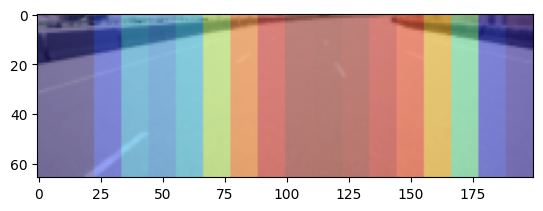

True Label:0.02001,Predicted Label:0.00785


In [24]:
cam_layer=model.cnn_layer[8]
Gradcam_visualize(model,df_test_ClearNoon[211],cam_layer)

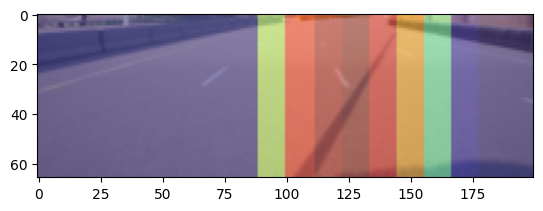

True Label:0.01957,Predicted Label:0.06467


In [25]:
Gradcam_visualize(model,df_test_ClearSunset[341],cam_layer)

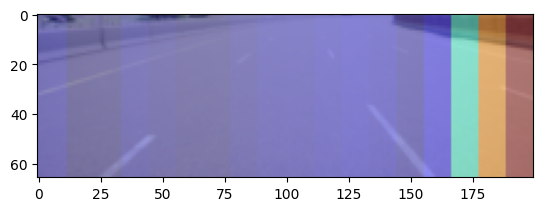

True Label:0.02045,Predicted Label:-0.00483


In [26]:
Gradcam_visualize(model,df_test_CloudyNoon[673],cam_layer)

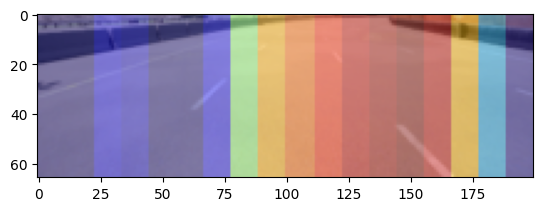

True Label:0.01899,Predicted Label:0.00833


In [27]:
Gradcam_visualize(model,df_test_WetNoon[139],cam_layer)

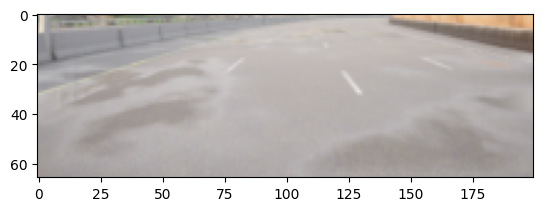

True Label:0.01869,Predicted Label:0.01143


In [28]:
Gradcam_visualize(model,df_test_MidRainSunset[198],cam_layer)

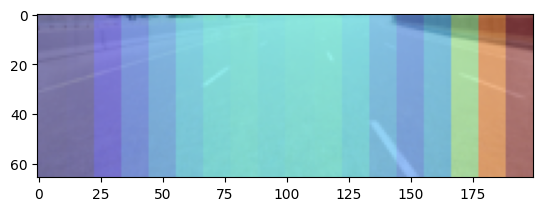

True Label:0.02215,Predicted Label:-0.01273


In [29]:
Gradcam_visualize(model,df_test_HardRainNoon[779],cam_layer)